# Week11 - Logistic Regression
# ADV Python for DS

Revised from Jose Portilla's course

---

For this lecture we will be working with the Titanic Data Set from Kaggle. This is a very famous data set and very often is a student's first step in machine learning.

**Goal:** To predict a classification- survival or deceased.

**Dataset:** Titanic Data Set


*Variables*

1) survival:	Survival	(0 = No, 1 = Yes)

2) pclass:	Ticket class	(1 = 1st, 2 = 2nd, 3 = 3rd)

3) sex:	Sex

4) Age:	Age in years

5) sibsp:	# of siblings / spouses aboard the Titanic

6) parch:	# of parents / children aboard the Titanic

7) ticket:	Ticket number

8) fare:	Passenger fare

9) cabin:	Cabin number

10) embarked:	Port of Embarkation	(C = Cherbourg, Q = Queenstown, S = Southampton)

# **1) Check out the data**

In [1]:
# Import commonly used data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inline in the notebook
%matplotlib inline

# Set a pleasant seaborn style
sns.set_style('whitegrid')


1.1) Read in the titanic_train.csv file into a pandas dataframe 'df_train'.

In [2]:
# Read the titanic_train.csv file into a pandas dataframe named df
csv_path = 'titanic_train.csv'

df = pd.read_csv(csv_path)

# Quick confirmation of load
print(f"Loaded DataFrame with shape: {df.shape}")


Loaded DataFrame with shape: (891, 12)


1.2) Check the head of titanic_train, and check out its info() and describe() methods.

In [3]:
# Show the first five rows to inspect the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Display concise summary of the dataframe
print("DataFrame info:\n")
df.info()

# Show the number of missing values per column
print('\nMissing values per column:')
print(df.isnull().sum())

DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin    

In [5]:
# Show summary statistics for numeric columns

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 2) Exploratory Data Analysis (EDA)

Let's begin some exploratory data analysis! We'll start by checking out missing data!

2.1) Missing Data

We can use seaborn to create a simple heatmap to see where we are missing data!

<Axes: >

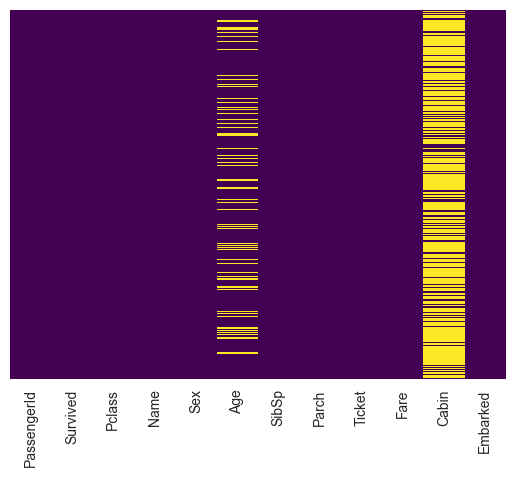

In [6]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Remark: Roughly 20% of the Age data is missing.

The proportion of Age missing is likely small enough for reasonable replacement with some form of imputation.

Looking at the Cabin column, it looks like we are just missing too much of that data to do something useful with at a basic level.

We'll probably drop this later, or change it to another feature like "Cabin Known: 1 or 0"

2.2) Use seaborn to create a countplot of 'Survived'

/var/folders/jq/5yznt0w97x730jm2dx9q6ylh0000gn/T/ipykernel_48971/1415311987.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Survived', data=df, palette='pastel')


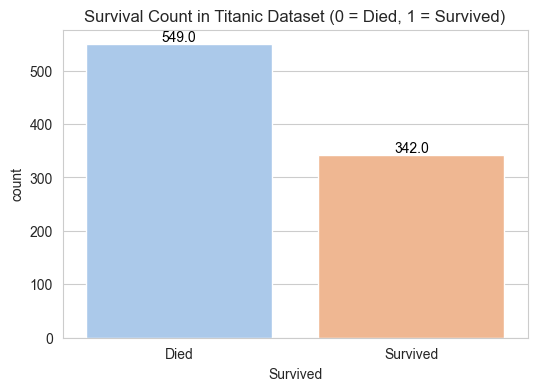

In [7]:
sns.set_style('whitegrid')
# Create the countplot for 'Survived'
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Survived', data=df, palette='pastel')

# Add a title for clarity
plt.title('Survival Count in Titanic Dataset (0 = Died, 1 = Survived)')

# Add meaningful x-tick labels
plt.xticks([0, 1], ['Died', 'Survived'])

# Annotate counts on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Display the plot
plt.show()

2.3) Use seaborn to create a countplot of 'Survived' with Hue = 'Sex'

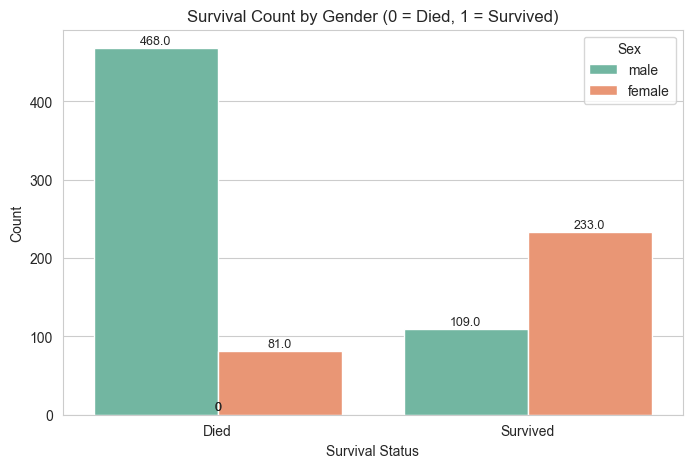

In [8]:
sns.set_style('whitegrid')
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Survived', hue='Sex', data=df, palette='Set2')

# Add a title and axis labels for clarity
plt.title('Survival Count by Gender (0 = Died, 1 = Survived)')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.xlabel('Survival Status')
plt.ylabel('Count')

# Annotate counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', fontsize=9, xytext=(0, 5), textcoords='offset points')

plt.show()

2.4) Use seaborn to create a countplot of 'Survived' with Hue = 'Pclass'

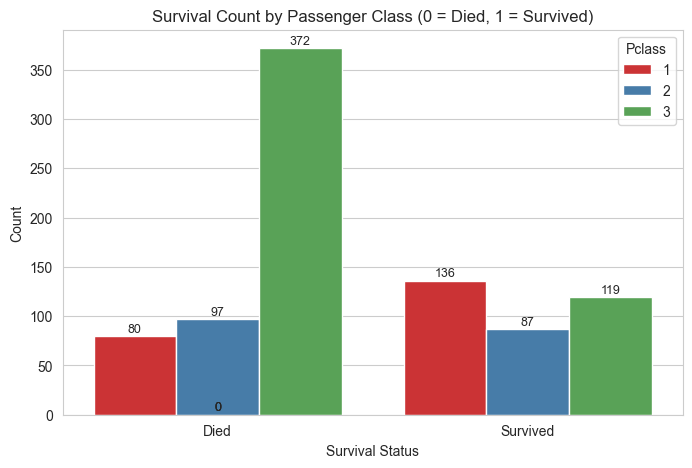

In [9]:
sns.set_style('whitegrid')
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set1')

# Add a title and axis labels for clarity
plt.title('Survival Count by Passenger Class (0 = Died, 1 = Survived)')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.xlabel('Survival Status')
plt.ylabel('Count')

# Annotate counts on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', fontsize=9, xytext=(0, 5), textcoords='offset points')

plt.show()

2.5) Use seaborn to create a distplot of 'Age' with bins = 30

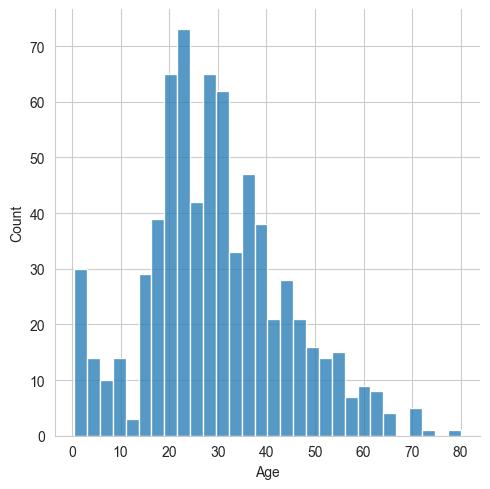

In [10]:
sns.displot(df['Age'], kde=False, bins=30)

2.6) Use seaborn to create a countplot of 'SibSp'

/var/folders/jq/5yznt0w97x730jm2dx9q6ylh0000gn/T/ipykernel_48971/2635389119.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='SibSp', data=df, palette='cool')


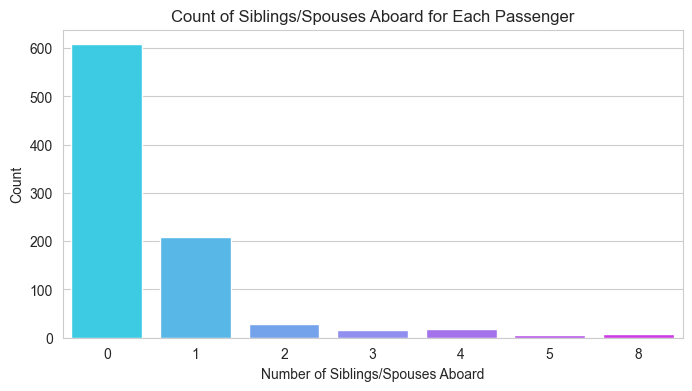

In [11]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='SibSp', data=df, palette='cool')

# Add a title for clarity
plt.title('Count of Siblings/Spouses Aboard for Each Passenger')
plt.xlabel('Number of Siblings/Spouses Aboard')
plt.ylabel('Count')

# Rotate x ticks if necessary
plt.xticks(rotation=0)

plt.show()

2.7) Use seaborn to create a histogram of 'Fare'

<Axes: >

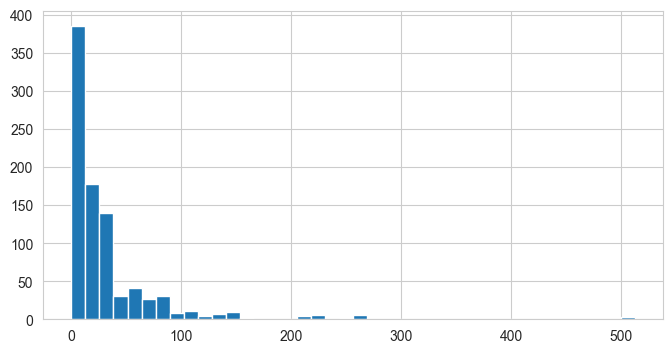

In [12]:
df['Fare'].hist(bins=40,figsize=(8,4))

___
# 3) Data Cleaning

3.1) We want to fill in missing age data instead of just dropping the missing age data rows.

One way to do this is by filling in the mean age of all the passengers (imputation).

However we can be smarter about this and check the average age by passenger class. For example:


<Axes: xlabel='Pclass', ylabel='Age'>

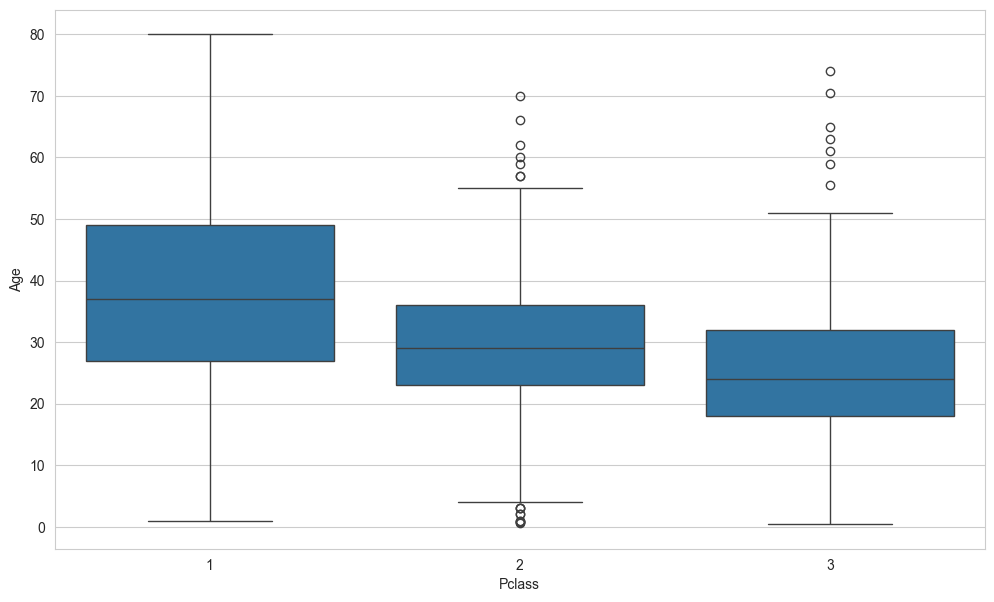

In [13]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass',y='Age',data=df)

3.2) We can see the wealthier passengers in the higher classes tend to be older, which makes sense.

We'll use these average age values to impute based on Pclass for Age.

Define imputation function and apply it

In [14]:
# define imputation function
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

In [15]:
df['Age'] = df[['Age','Pclass']].apply(impute_age,axis=1)

/var/folders/jq/5yznt0w97x730jm2dx9q6ylh0000gn/T/ipykernel_48971/1176681115.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/var/folders/jq/5yznt0w97x730jm2dx9q6ylh0000gn/T/ipykernel_48971/1176681115.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


3.3) Check that heat map again

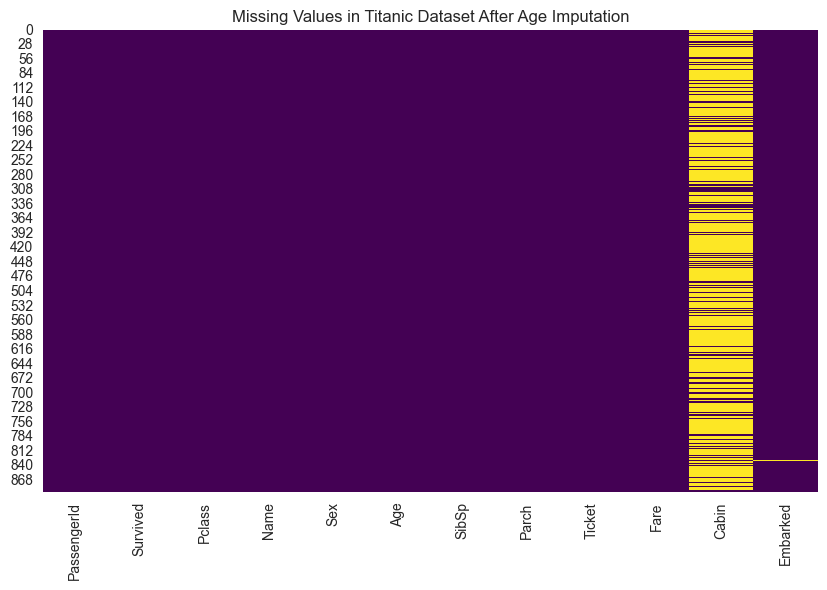

In [16]:
# Create the heatmap to visualize missing values
plt.figure(figsize=(10, 6)) # Adjust figure size if needed
sns.heatmap(df.isnull(), cbar=False, cmap='viridis') # cbar=False hides the color bar as it's binary data (True/False)
plt.title('Missing Values in Titanic Dataset After Age Imputation')
plt.show()

3.4) Drop the Cabin column and the row in Embarked that is NaN.

In [17]:
df.drop('Cabin', axis=1, inplace=True)

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [19]:
df.dropna(inplace=True)

3.5) Converting Categorical Features

We'll need to convert categorical features to dummy variables using pandas.

Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [21]:
# Create dummy variables for 'Sex' and 'Embarked'
sex_dummies = pd.get_dummies(df['Sex'], drop_first=True)
embark_dummies = pd.get_dummies(df['Embarked'], drop_first=True)

In [22]:
sex_dummies.head()

,male
0,True
1,False
2,False
3,False
4,True


In [23]:
embark_dummies.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [24]:
# Drop the columns that are not needed anymore
columns_to_drop = ['Sex', 'Embarked', 'Name', 'Ticket']
df.drop(columns=columns_to_drop, inplace=True)

# Confirm dropped columns
print('Columns after drop:', df.columns.tolist())

Columns after drop: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [25]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [26]:
# Concatenate 'sex' and 'embark' to df
df = pd.concat([df, sex_dummies, embark_dummies], axis=1)

In [27]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


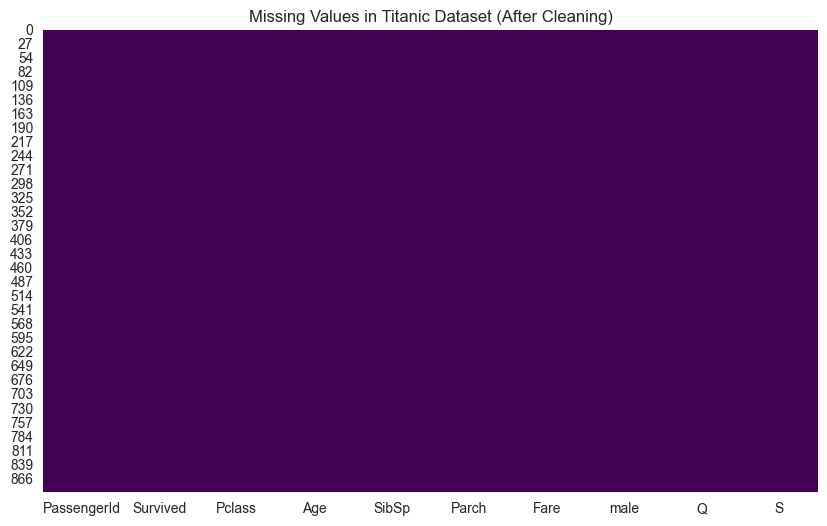

In [28]:
# Check that heat map again after cleaning and adding dummy variables
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Titanic Dataset (After Cleaning)')
plt.show()


# 4) Building a Logistic Regression model


4.1) Train Test Split

In [29]:
# Import scikit learn: train_test_split

from sklearn.model_selection import train_test_split


In [30]:
# Apply 'train_test_split' with test_size=0.30 and random_state=101

# Define your features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Apply the train_test_split with the specified parameters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

# Optional: Print the shapes to verify the split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (622, 9)
X_test shape: (267, 9)
y_train shape: (622,)
y_test shape: (267,)


4.2) Training and Predicting

In [31]:
# Import scikit learn: LogisticRegression

from sklearn.linear_model import LogisticRegression


In [32]:
# Create a LogisticRegression named as 'logmodel', an instance of the LogisticRegression model
logmodel = LogisticRegression(max_iter=1000)

# Fit the 'logmodel'
Everything You Need to Know About Logistic Regression ...
To fit your logmodel to the training data, you call the .fit() method on your logmodel object, passing it your training features (X_train) and your training labels (y_train).

In [33]:
# Fit the 'logmodel'
logmodel.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
predictions = logmodel.predict(X_test)

In [35]:
predictions

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

# 5) Evaluation

We can check precision,recall,f1-score using classification report!

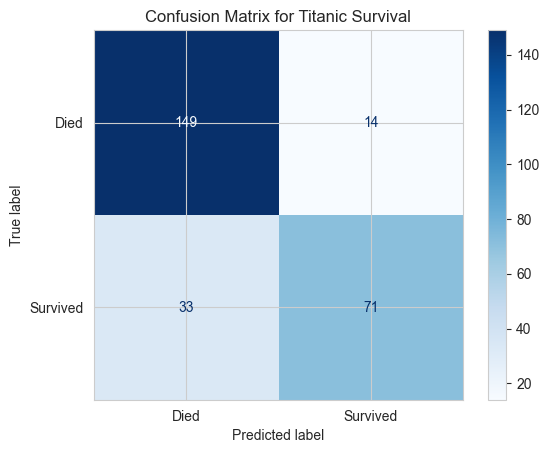

In [36]:
# Create ConfusionMatrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, predictions)

# 2. Create the ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])


disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Titanic Survival')
plt.show()


sklearn.metrics.ConfusionMatrixDisplay



https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html



In [37]:
# classification_report
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.82      0.91      0.86       163
           1       0.84      0.68      0.75       104

    accuracy                           0.82       267
   macro avg       0.83      0.80      0.81       267
weighted avg       0.83      0.82      0.82       267



Interpretation of the classification report
The output will be a text report showing the main classification metrics for each class (typically 0 for "Died" and 1 for "Survived" in the Titanic dataset), along with overall averages.
* precision: The accuracy of the positive predictions.
* recall: The fraction of positives that were correctly identified.
* f1-score: The weighted average of precision and recall.
* support: The number of actual occurrences of the class in the test set.

This report is essential for evaluating your model's performance beyond simple accuracy, especially in cases where the dataset is imbalanced.

sklearn.metrics.precision_recall_fscore_support

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support

Not so bad! You might want to explore other feature engineering and the other titanic_text.csv file, some suggestions for feature engineering:

* Try grabbing the Title (Dr.,Mr.,Mrs,etc..) from the name as a feature
* Maybe the Cabin letter could be a feature
* Is there any info you can get from the ticket?

## Great Job!